1. Fetching Daily Macro Data...
2. Fetching 1H Forex Data for Portfolio...
   >> EURUSD=X
   >> GBPUSD=X
   >> JPY=X

--- INDIVIDUAL PERFORMANCE (Risk: 1%) ---
PAIR       TRADES   WIN RATE   REAL RR    EV ($)     RETURN    
---------------------------------------------------------------------------
EURUSD=X   69         23.2%     3.25R    $ -1.39       -0.96%
GBPUSD=X   84         22.6%     3.44R    $  0.44        0.37%
JPY=X      70         18.6%     4.17R    $ -2.91       -2.04%
---------------------------------------------------------------------------

--- TOTAL PORTFOLIO METRICS ---
Total Trades:    223
Overall WR:      21.52%
Realized RR:     3.58R
Exp. Value (EV): $-1.18 per trade
Final Balance:   $9,737.14
Total Return:    -2.63%
Sharpe Ratio:    -2.92
Alpha (Annual):  -0.7060


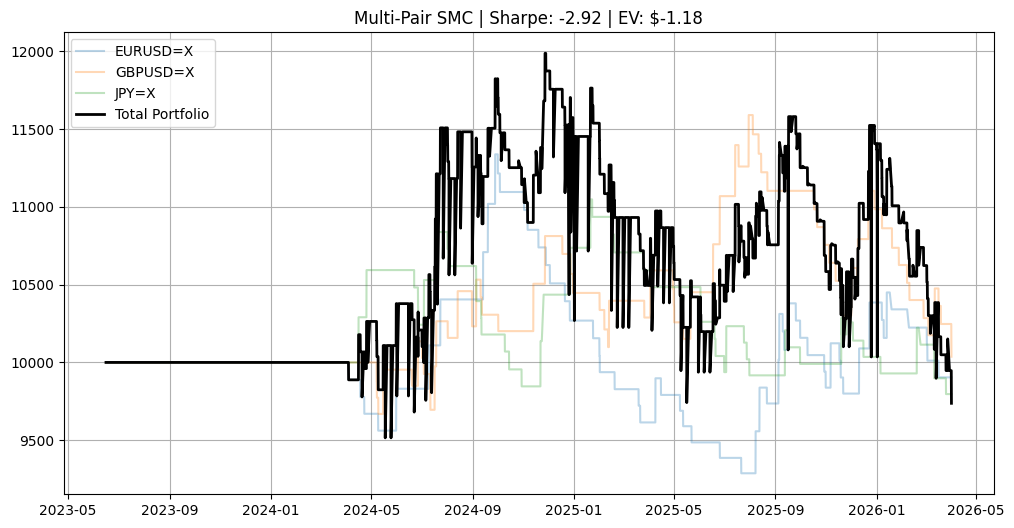

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- CONFIGURATION ---
PAIRS_TO_TRADE = ['EURUSD=X', 'GBPUSD=X', 'JPY=X'] 
TICKERS_MACRO = ['SPY', 'FEZ', '^TNX', 'CL=F'] 
INITIAL_CAPITAL = 10000
RISK_PCT = 0.01            # 1% Risk per trade
SPREAD_PIPS = 1.5      
PIP_SIZE = 0.0001

# --- 1. DATA LOADER ---
def get_data(tickers_fx):
    print("1. Fetching Daily Macro Data...")
    macro = yf.download(TICKERS_MACRO, period="2y", interval="1d", progress=False)['Close']
    macro = macro.ffill().dropna()
    
    fx_data = {}
    print("2. Fetching 1H Forex Data for Portfolio...")
    for ticker in tickers_fx:
        print(f"   >> {ticker}")
        df = yf.download(ticker, period="730d", interval="1h", progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            try: df = df.xs(ticker, level=1, axis=1)
            except: pass
        df.index = df.index.tz_localize(None)
        fx_data[ticker] = df.dropna()
        
    return macro, fx_data

# --- 2. MACRO BIAS ---
def get_macro_bias(macro_df):
    lb = 50
    growth = macro_df['SPY'] / macro_df['FEZ']
    score_growth = np.where(growth > growth.ewm(span=lb).mean(), -1, 1) 
    score_yield = np.where(macro_df['^TNX'] > macro_df['^TNX'].ewm(span=lb).mean(), -1, 1) 
    score_oil = np.where(macro_df['CL=F'] > macro_df['CL=F'].ewm(span=lb).mean(), -1, 1) 
    
    macro_df['Bias_Score'] = score_growth + score_yield + score_oil
    macro_df['Daily_Bias'] = 0
    macro_df.loc[macro_df['Bias_Score'] >= 1, 'Daily_Bias'] = 1  
    macro_df.loc[macro_df['Bias_Score'] <= -1, 'Daily_Bias'] = -1 
    return macro_df[['Daily_Bias']].shift(1).fillna(0)

# --- 3. HELPER: KILLZONES ---
def is_killzone(timestamp):
    h = timestamp.hour
    if (h >= 7 and h <= 10) or (h >= 12 and h <= 16):
        return True
    return False

# --- 4. CORE ENGINE ---
def backtest_pair(ticker, fx_df, macro_bias):
    current_pip = PIP_SIZE
    if "JPY" in ticker or fx_df['Close'].iloc[-1] > 50:
        current_pip = 0.01
        
    aligned_bias = macro_bias['Daily_Bias'].reindex(fx_df.index, method='ffill').fillna(0)
    fx_df['Bias'] = aligned_bias
    
    fx_df['TR'] = np.maximum(fx_df['High'] - fx_df['Low'], abs(fx_df['Close'] - fx_df['Close'].shift(1)))
    fx_df['ATR'] = fx_df['TR'].rolling(14).mean()
    
    balance = INITIAL_CAPITAL
    equity_curve = []
    trades = [] 
    
    position = 0 
    entry_price = 0
    stop_loss = 0
    take_profit = 0
    units = 0
    
    active_eqh = []
    active_eql = []
    
    for i in range(20, len(fx_df)):
        ts = fx_df.index[i]
        o, h, l, c = fx_df['Open'].iloc[i], fx_df['High'].iloc[i], fx_df['Low'].iloc[i], fx_df['Close'].iloc[i]
        bias = fx_df['Bias'].iloc[i]
        atr = fx_df['ATR'].iloc[i]
        
        if np.isnan(atr): 
            equity_curve.append(balance)
            continue

        c_ref = i - 2
        if (fx_df['High'].iloc[c_ref] > fx_df['High'].iloc[c_ref-1]) and \
           (fx_df['High'].iloc[c_ref] > fx_df['High'].iloc[c_ref+1]) and \
           (fx_df['High'].iloc[c_ref] > fx_df['High'].iloc[i]):
            lvl = fx_df['High'].iloc[c_ref]
            if not any(abs(lvl - x) < (5 * current_pip) for x in active_eqh):
                active_eqh.append(lvl)
                
        if (fx_df['Low'].iloc[c_ref] < fx_df['Low'].iloc[c_ref-1]) and \
           (fx_df['Low'].iloc[c_ref] < fx_df['Low'].iloc[c_ref+1]) and \
           (fx_df['Low'].iloc[c_ref] < fx_df['Low'].iloc[i]):
            lvl = fx_df['Low'].iloc[c_ref]
            if not any(abs(lvl - x) < (5 * current_pip) for x in active_eql):
                active_eql.append(lvl)

        if position != 0:
            risk_dist = abs(entry_price - stop_loss)
            pnl = 0
            trade_res = None
            
            if position == 1:
                if l <= stop_loss:
                    pnl = (stop_loss - entry_price) * units
                    pnl -= (SPREAD_PIPS * current_pip * units)
                    trade_res = 'Loss'
                elif h >= take_profit:
                    pnl = (take_profit - entry_price) * units
                    pnl -= (SPREAD_PIPS * current_pip * units)
                    trade_res = 'Win'
                elif (h - entry_price) > (1.5 * risk_dist) and stop_loss < entry_price:
                    stop_loss = entry_price + (SPREAD_PIPS * current_pip)

            elif position == -1:
                if h >= stop_loss:
                    pnl = (entry_price - stop_loss) * units
                    pnl -= (SPREAD_PIPS * current_pip * units)
                    trade_res = 'Loss'
                elif l <= take_profit:
                    pnl = (entry_price - take_profit) * units
                    pnl -= (SPREAD_PIPS * current_pip * units)
                    trade_res = 'Win'
                elif (entry_price - l) > (1.5 * risk_dist) and stop_loss > entry_price:
                    stop_loss = entry_price - (SPREAD_PIPS * current_pip)

            if trade_res:
                balance += pnl
                trades.append({'Result': trade_res, 'PnL': pnl, 'Pair': ticker})
                position = 0

        active_eqh = [lvl for lvl in active_eqh if h < lvl]
        active_eql = [lvl for lvl in active_eql if l > lvl]
        
        if position == 0 and is_killzone(ts):
            body = abs(c - o)
            rng = h - l
            displacement = body > (0.5 * rng)
            
            if displacement:
                if bias == 1:
                    prev_lows = fx_df['Low'].iloc[i-24:i].min()
                    if l < prev_lows and c > prev_lows:
                        position = 1
                        entry_price = c + (SPREAD_PIPS * current_pip)
                        stop_loss = l - (0.5 * atr)
                        risk = entry_price - stop_loss
                        if risk > 0:
                            take_profit = entry_price + (3 * risk)
                            units = (balance * RISK_PCT) / risk
                
                elif bias == -1:
                    prev_highs = fx_df['High'].iloc[i-24:i].max()
                    if h > prev_highs and c < prev_highs:
                        position = -1
                        entry_price = c 
                        stop_loss = h + (0.5 * atr)
                        risk = stop_loss - entry_price
                        if risk > 0:
                            take_profit = entry_price - (3 * risk)
                            units = (balance * RISK_PCT) / risk

        equity_curve.append(balance)

    return pd.Series(equity_curve, index=fx_df.index[-len(equity_curve):]), trades

# --- 5. RUNNER & STATS ---
if __name__ == "__main__":
    macro_df, fx_data = get_data(PAIRS_TO_TRADE)
    macro_bias = get_macro_bias(macro_df)
    
    portfolio_curve = None
    all_trades = []
    
    plt.figure(figsize=(12, 6))
    
    print("\n--- INDIVIDUAL PERFORMANCE (Risk: 1%) ---")
    # Added EV Column
    print(f"{'PAIR':<10} {'TRADES':<8} {'WIN RATE':<10} {'REAL RR':<10} {'EV ($)':<10} {'RETURN':<10}")
    print("-" * 75)
    
    for ticker, df in fx_data.items():
        curve, trades = backtest_pair(ticker, df, macro_bias)
        
        wins = [t['PnL'] for t in trades if t['Result'] == 'Win']
        losses = [t['PnL'] for t in trades if t['Result'] == 'Loss']
        pair_total = len(trades)
        
        # 1. Win Rate
        pair_wr = (len(wins) / pair_total) if pair_total > 0 else 0
        
        # 2. Avg Win / Loss
        avg_win = np.mean(wins) if wins else 0
        avg_loss = np.mean(losses) if losses else 0 # this is negative
        
        # 3. Realized RR
        realized_rr = abs(avg_win / avg_loss) if avg_loss != 0 else 0
        
        # 4. Expected Value (EV)
        # EV = (Win% * AvgWin) + (Loss% * AvgLoss) -> Note: AvgLoss is negative here
        ev_trade = (pair_wr * avg_win) + ((1 - pair_wr) * avg_loss)
        
        # 5. Return
        pair_ret = ((curve.iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100
        
        print(f"{ticker:<10} {str(pair_total):<8} {pair_wr*100:>6.1f}%   {realized_rr:>6.2f}R    ${ev_trade:>6.2f}    {pair_ret:>8.2f}%")
        
        norm_curve = curve - INITIAL_CAPITAL
        if portfolio_curve is None:
            portfolio_curve = norm_curve
        else:
            portfolio_curve = portfolio_curve.add(norm_curve, fill_value=0)
            
        all_trades.extend(trades)
        plt.plot(curve, alpha=0.3, label=f"{ticker}")

    # Portfolio Stats
    portfolio_final = portfolio_curve + INITIAL_CAPITAL
    portfolio_final.index = pd.to_datetime(portfolio_final.index)
    
    all_wins = [t['PnL'] for t in all_trades if t['Result'] == 'Win']
    all_losses = [t['PnL'] for t in all_trades if t['Result'] == 'Loss']
    
    total_trades = len(all_trades)
    win_rate = (len(all_wins) / total_trades) if total_trades > 0 else 0
    
    avg_win_port = np.mean(all_wins) if all_wins else 0
    avg_loss_port = np.mean(all_losses) if all_losses else 0
    port_rr = abs(avg_win_port / avg_loss_port) if avg_loss_port != 0 else 0
    
    # Portfolio EV
    port_ev = (win_rate * avg_win_port) + ((1 - win_rate) * avg_loss_port)
    
    daily_rets = portfolio_final.resample('D').last().pct_change().dropna()
    sharpe = (daily_rets.mean() / daily_rets.std()) * (252**0.5) if daily_rets.std() > 0 else 0
    
    spy_rets = macro_df['SPY'].pct_change().reindex(daily_rets.index).fillna(0)
    slope, intercept, r_value, p_value, std_err = stats.linregress(spy_rets, daily_rets)
    alpha_annual = intercept * 252 
    beta = slope
    
    print("-" * 75)
    print(f"\n--- TOTAL PORTFOLIO METRICS ---")
    print(f"Total Trades:    {total_trades}")
    print(f"Overall WR:      {win_rate*100:.2f}%")
    print(f"Realized RR:     {port_rr:.2f}R")
    print(f"Exp. Value (EV): ${port_ev:.2f} per trade")
    print(f"Final Balance:   ${portfolio_final.iloc[-1]:,.2f}")
    print(f"Total Return:    {((portfolio_final.iloc[-1] - INITIAL_CAPITAL)/INITIAL_CAPITAL)*100:.2f}%")
    print(f"Sharpe Ratio:    {sharpe:.2f}")
    print(f"Alpha (Annual):  {alpha_annual:.4f}")

    plt.plot(portfolio_final, color='black', linewidth=2, label='Total Portfolio')
    plt.title(f'Multi-Pair SMC | Sharpe: {sharpe:.2f} | EV: ${port_ev:.2f}')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- CONFIGURATION ---
# Now trading Bitcoin, S&P 500, and Gold
ASSETS_TO_TRADE = ['BTC-USD', 'SPY', 'GC=F'] 
TICKERS_MACRO = ['SPY', 'FEZ', '^TNX', 'CL=F'] 

INITIAL_CAPITAL = 10000
RISK_PCT = 0.01   # 1% Risk per trade

# --- 1. DYNAMIC INSTRUMENT CONFIG ---
def get_instrument_config(ticker, current_price):
    """
    Returns (tick_size, spread_cost_in_price_units)
    """
    # 1. BITCOIN (Crypto)
    if "BTC" in ticker:
        return 0.01, 10.00  # $10 spread per coin
    
    # 2. GOLD (Futures/Commodity)
    elif "GC=" in ticker:
        return 0.10, 0.40   # $0.40 spread
    
    # 3. SPY (Stocks)
    elif "SPY" in ticker:
        return 0.01, 0.03   # $0.03 spread
    
    # 4. FOREX (Fallback)
    elif "JPY" in ticker or current_price > 50: # JPY Pairs
        return 0.01, 0.015 
    else: # Standard Forex
        return 0.0001, 0.00015

# --- 2. DATA LOADER ---
def get_data(tickers_trade):
    print("1. Fetching Daily Macro Data...")
    macro = yf.download(TICKERS_MACRO, period="2y", interval="1d", progress=False)['Close']
    macro = macro.ffill().dropna()
    
    asset_data = {}
    print("2. Fetching 1H Asset Data...")
    for ticker in tickers_trade:
        print(f"   >> {ticker}")
        # Fetch 730 days of 1h data
        df = yf.download(ticker, period="730d", interval="1h", progress=False)
        
        if isinstance(df.columns, pd.MultiIndex):
            try: df = df.xs(ticker, level=1, axis=1)
            except: pass
        
        df.index = df.index.tz_localize(None)
        asset_data[ticker] = df.dropna()
        
    return macro, asset_data

# --- 3. MACRO BIAS ---
def get_macro_bias(macro_df):
    lb = 50
    # Growth (Stocks vs Europe)
    growth = macro_df['SPY'] / macro_df['FEZ']
    score_growth = np.where(growth > growth.ewm(span=lb).mean(), -1, 1) 
    # Yields (10Y)
    score_yield = np.where(macro_df['^TNX'] > macro_df['^TNX'].ewm(span=lb).mean(), -1, 1) 
    # Oil
    score_oil = np.where(macro_df['CL=F'] > macro_df['CL=F'].ewm(span=lb).mean(), -1, 1) 
    
    # Bias Score: Positive = Risk On (Long Stocks/Crypto), Negative = Risk Off
    macro_df['Bias_Score'] = score_growth + score_yield + score_oil
    
    macro_df['Daily_Bias'] = 0
    # Note: Logic assumes Risk On = Bullish for BTC/SPY. 
    # Gold is complex but often trades with liquidity (Risk On).
    macro_df.loc[macro_df['Bias_Score'] >= 1, 'Daily_Bias'] = 1  
    macro_df.loc[macro_df['Bias_Score'] <= -1, 'Daily_Bias'] = -1 
    
    return macro_df[['Daily_Bias']].shift(1).fillna(0)

# --- 4. KILLZONES (NY Session Focus) ---
def is_active_session(timestamp):
    # For Stocks/Crypto/Gold, NY Session (13:00 - 21:00 UTC) is liquid
    # Adjusted for general "US Trading Hours" overlap
    h = timestamp.hour
    if h >= 13 and h <= 21:
        return True
    return False

# --- 5. CORE ENGINE ---
def backtest_asset(ticker, df, macro_bias):
    # Align Bias
    aligned_bias = macro_bias['Daily_Bias'].reindex(df.index, method='ffill').fillna(0)
    df['Bias'] = aligned_bias
    
    # ATR
    df['TR'] = np.maximum(df['High'] - df['Low'], abs(df['Close'] - df['Close'].shift(1)))
    df['ATR'] = df['TR'].rolling(14).mean()
    
    # Tick/Spread Settings
    tick_size, spread_val = get_instrument_config(ticker, df['Close'].iloc[-1])
    
    balance = INITIAL_CAPITAL
    equity_curve = []
    trades = [] 
    
    position = 0 
    entry_price = 0
    stop_loss = 0
    take_profit = 0
    units = 0
    
    active_eqh = []
    active_eql = []
    
    for i in range(20, len(df)):
        ts = df.index[i]
        o, h, l, c = df['Open'].iloc[i], df['High'].iloc[i], df['Low'].iloc[i], df['Close'].iloc[i]
        bias = df['Bias'].iloc[i]
        atr = df['ATR'].iloc[i]
        
        if np.isnan(atr): 
            equity_curve.append(balance)
            continue

        # --- FRACTAL LOGIC ---
        c_ref = i - 2
        # Pivot High
        if (df['High'].iloc[c_ref] > df['High'].iloc[c_ref-1]) and \
           (df['High'].iloc[c_ref] > df['High'].iloc[c_ref+1]) and \
           (df['High'].iloc[c_ref] > df['High'].iloc[i]):
            lvl = df['High'].iloc[c_ref]
            # Check duplicates using tick size buffer
            if not any(abs(lvl - x) < (5 * tick_size) for x in active_eqh):
                active_eqh.append(lvl)
                
        # Pivot Low
        if (df['Low'].iloc[c_ref] < df['Low'].iloc[c_ref-1]) and \
           (df['Low'].iloc[c_ref] < df['Low'].iloc[c_ref+1]) and \
           (df['Low'].iloc[c_ref] < df['Low'].iloc[i]):
            lvl = df['Low'].iloc[c_ref]
            if not any(abs(lvl - x) < (5 * tick_size) for x in active_eql):
                active_eql.append(lvl)

        # --- TRADE MANAGEMENT ---
        if position != 0:
            risk_dist = abs(entry_price - stop_loss)
            pnl = 0
            trade_res = None
            
            if position == 1:
                if l <= stop_loss:
                    pnl = (stop_loss - entry_price) * units
                    pnl -= (spread_val * units) # Spread Cost
                    trade_res = 'Loss'
                elif h >= take_profit:
                    pnl = (take_profit - entry_price) * units
                    pnl -= (spread_val * units)
                    trade_res = 'Win'
                elif (h - entry_price) > (1.5 * risk_dist) and stop_loss < entry_price:
                    stop_loss = entry_price + spread_val # BE + Spread

            elif position == -1:
                if h >= stop_loss:
                    pnl = (entry_price - stop_loss) * units
                    pnl -= (spread_val * units)
                    trade_res = 'Loss'
                elif l <= take_profit:
                    pnl = (entry_price - take_profit) * units
                    pnl -= (spread_val * units)
                    trade_res = 'Win'
                elif (entry_price - l) > (1.5 * risk_dist) and stop_loss > entry_price:
                    stop_loss = entry_price - spread_val

            if trade_res:
                balance += pnl
                trades.append({'Result': trade_res, 'PnL': pnl, 'Pair': ticker})
                position = 0

        # --- ENTRY LOGIC ---
        active_eqh = [lvl for lvl in active_eqh if h < lvl]
        active_eql = [lvl for lvl in active_eql if l > lvl]
        
        if position == 0 and is_active_session(ts):
            body = abs(c - o)
            rng = h - l
            # Stricter displacement for Crypto/Stocks (0.6)
            displacement = body > (0.6 * rng)
            
            if displacement:
                # LONG
                if bias == 1:
                    prev_lows = df['Low'].iloc[i-24:i].min()
                    if l < prev_lows and c > prev_lows:
                        position = 1
                        entry_price = c + spread_val
                        stop_loss = l - (0.5 * atr)
                        risk = entry_price - stop_loss
                        if risk > 0:
                            take_profit = entry_price + (3 * risk)
                            units = (balance * RISK_PCT) / risk
                
                # SHORT
                elif bias == -1:
                    prev_highs = df['High'].iloc[i-24:i].max()
                    if h > prev_highs and c < prev_highs:
                        position = -1
                        entry_price = c 
                        stop_loss = h + (0.5 * atr)
                        risk = stop_loss - entry_price
                        if risk > 0:
                            take_profit = entry_price - (3 * risk)
                            units = (balance * RISK_PCT) / risk

        equity_curve.append(balance)

    return pd.Series(equity_curve, index=df.index[-len(equity_curve):]), trades

# --- 6. RUNNER ---
if __name__ == "__main__":
    macro_df, asset_data = get_data(ASSETS_TO_TRADE)
    macro_bias = get_macro_bias(macro_df)
    
    portfolio_curve = None
    all_trades = []
    
    plt.figure(figsize=(12, 6))
    
    print("\n--- ASSET PERFORMANCE (Risk: 1%) ---")
    print(f"{'TICKER':<10} {'TRADES':<8} {'WIN RATE':<10} {'REAL RR':<10} {'EV ($)':<10} {'MAX DD':<10} {'RETURN'}")
    print("-" * 85)
    
    for ticker, df in asset_data.items():
        curve, trades = backtest_asset(ticker, df, macro_bias)
        
        wins = [t['PnL'] for t in trades if t['Result'] == 'Win']
        losses = [t['PnL'] for t in trades if t['Result'] == 'Loss']
        total = len(trades)
        
        # Stats
        wr = (len(wins) / total) if total > 0 else 0
        avg_win = np.mean(wins) if wins else 0
        avg_loss = np.mean(losses) if losses else 0
        rr = abs(avg_win / avg_loss) if avg_loss != 0 else 0
        ev = (wr * avg_win) + ((1 - wr) * avg_loss)
        
        # Drawdown
        dd_series = ((curve - curve.cummax()) / curve.cummax()) * 100
        max_dd = dd_series.min()
        
        ret = ((curve.iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100
        
        print(f"{ticker:<10} {str(total):<8} {wr*100:>6.1f}%   {rr:>6.2f}R    ${ev:>6.2f}    {max_dd:>6.2f}%   {ret:>8.2f}%")
        
        # Aggregate
        norm_curve = curve - INITIAL_CAPITAL
        if portfolio_curve is None:
            portfolio_curve = norm_curve
        else:
            portfolio_curve = portfolio_curve.add(norm_curve, fill_value=0)
            
        all_trades.extend(trades)
        plt.plot(curve, alpha=0.3, label=f"{ticker}")

    # --- PORTFOLIO ---
    portfolio_final = portfolio_curve + INITIAL_CAPITAL
    portfolio_final.index = pd.to_datetime(portfolio_final.index)
    
    # Portfolio Max DD
    port_dd_series = ((portfolio_final - portfolio_final.cummax()) / portfolio_final.cummax()) * 100
    port_max_dd = port_dd_series.min()
    
    # Portfolio Metrics
    all_wins = [t['PnL'] for t in all_trades if t['Result'] == 'Win']
    all_losses = [t['PnL'] for t in all_trades if t['Result'] == 'Loss']
    total_trades = len(all_trades)
    
    win_rate = (len(all_wins) / total_trades) if total_trades > 0 else 0
    avg_win_port = np.mean(all_wins) if all_wins else 0
    avg_loss_port = np.mean(all_losses) if all_losses else 0
    port_rr = abs(avg_win_port / avg_loss_port) if avg_loss_port != 0 else 0
    port_ev = (win_rate * avg_win_port) + ((1 - win_rate) * avg_loss_port)
    
    daily_rets = portfolio_final.resample('D').last().pct_change().dropna()
    sharpe = (daily_rets.mean() / daily_rets.std()) * (252**0.5) if daily_rets.std() > 0 else 0
    
    print("-" * 85)
    print(f"\n--- TOTAL PORTFOLIO METRICS ---")
    print(f"Total Trades:    {total_trades}")
    print(f"Overall WR:      {win_rate*100:.2f}%")
    print(f"Realized RR:     {port_rr:.2f}R")
    print(f"Exp. Value (EV): ${port_ev:.2f}")
    print(f"Portfolio DD:    {port_max_dd:.2f}%")
    print(f"Final Balance:   ${portfolio_final.iloc[-1]:,.2f}")
    print(f"Sharpe Ratio:    {sharpe:.2f}")

    plt.plot(portfolio_final, color='black', linewidth=2, label='Total Portfolio')
    plt.title(f'Portfolio (BTC, SPY, GC) | Max DD: {port_max_dd:.2f}% | Sharpe: {sharpe:.2f}')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- CONFIGURATION ---
# 1. ASSET UNIVERSE
ASSETS_FX = ['EURUSD=X', 'GBPUSD=X', 'JPY=X']
ASSETS_MACRO = ['BTC-USD', 'SPY', 'GC=F']
ALL_TICKERS = ASSETS_FX + ASSETS_MACRO

# 2. MACRO INDICATORS
TICKERS_DATA = ['SPY', 'FEZ', '^TNX', 'CL=F'] 

# 3. STRATEGY SETTINGS
INITIAL_CAPITAL = 10000
RISK_PCT = 0.01   # 1% Risk per trade

# --- 1. DYNAMIC ASSET CONFIGURATION ---
def get_asset_config(ticker, current_price):
    """
    Returns (tick_size, spread_cost, asset_class)
    """
    # A. BITCOIN
    if "BTC" in ticker:
        return 0.01, 12.00, 'CRYPTO' # $12 Spread
    
    # B. GOLD
    elif "GC=" in ticker:
        return 0.10, 0.40, 'COMMODITY' # $0.40 Spread
    
    # C. STOCKS (SPY)
    elif "SPY" in ticker:
        return 0.01, 0.03, 'STOCK'     # $0.03 Spread
    
    # D. FOREX (JPY)
    elif "JPY" in ticker or (current_price > 50 and "USD" not in ticker):
        return 0.01, 0.015, 'FOREX'    # 1.5 Pips (Jpy Scale)
        
    # E. FOREX (Standard)
    else:
        return 0.0001, 0.00015, 'FOREX' # 1.5 Pips (Standard Scale)

def get_trading_hours(ticker, timestamp):
    """
    Returns True if valid session for the specific asset.
    """
    h = timestamp.hour
    
    # Forex: Trade London (7-10) AND NY (12-16)
    if any(x in ticker for x in ['EUR', 'GBP', 'JPY', '=X']):
        if (h >= 7 and h <= 10) or (h >= 12 and h <= 16):
            return True
            
    # Stocks/Gold/Crypto: Trade NY Session Only (Liquidity)
    else:
        if h >= 13 and h <= 21: # 1:00 PM - 9:00 PM UTC
            return True
            
    return False

# --- 2. DATA LOADER ---
def get_data():
    print("1. Fetching Daily Macro Data...")
    macro = yf.download(TICKERS_DATA, period="2y", interval="1d", progress=False)['Close']
    macro = macro.ffill().dropna()
    
    asset_data = {}
    print("2. Fetching 1H Asset Data (Global Portfolio)...")
    for ticker in ALL_TICKERS:
        print(f"   >> {ticker}")
        try:
            df = yf.download(ticker, period="730d", interval="1h", progress=False)
            if isinstance(df.columns, pd.MultiIndex):
                df = df.xs(ticker, level=1, axis=1)
            
            df.index = df.index.tz_localize(None)
            asset_data[ticker] = df.dropna()
        except Exception as e:
            print(f"Error fetching {ticker}: {e}")
            
    return macro, asset_data

# --- 3. MACRO BIAS ENGINE ---
def get_macro_bias(macro_df):
    lb = 50
    # Growth (Stocks vs Europe)
    growth = macro_df['SPY'] / macro_df['FEZ']
    score_growth = np.where(growth > growth.ewm(span=lb).mean(), -1, 1) 
    # Yields (10Y)
    score_yield = np.where(macro_df['^TNX'] > macro_df['^TNX'].ewm(span=lb).mean(), -1, 1) 
    # Oil
    score_oil = np.where(macro_df['CL=F'] > macro_df['CL=F'].ewm(span=lb).mean(), -1, 1) 
    
    # Combined Score
    macro_df['Bias_Score'] = score_growth + score_yield + score_oil
    
    macro_df['Risk_State'] = 0
    # Score >= 1: Risk On (Buy Stocks/Crypto/Gold, Sell USD)
    # Score <= -1: Risk Off (Sell Stocks/Crypto, Buy USD)
    macro_df.loc[macro_df['Bias_Score'] >= 1, 'Risk_State'] = 1  
    macro_df.loc[macro_df['Bias_Score'] <= -1, 'Risk_State'] = -1 
    
    return macro_df[['Risk_State']].shift(1).fillna(0)

# --- 4. BACKTEST CORE ---
def run_backtest(ticker, df, macro_bias):
    # Align Bias
    aligned_bias = macro_bias['Risk_State'].reindex(df.index, method='ffill').fillna(0)
    df['Bias'] = aligned_bias
    
    # ATR
    df['TR'] = np.maximum(df['High'] - df['Low'], abs(df['Close'] - df['Close'].shift(1)))
    df['ATR'] = df['TR'].rolling(14).mean()
    
    # Config
    tick_size, spread, asset_class = get_asset_config(ticker, df['Close'].iloc[-1])
    
    balance = INITIAL_CAPITAL
    equity_curve = []
    trades = [] 
    
    position = 0 
    entry_price = 0
    stop_loss = 0
    take_profit = 0
    units = 0
    
    active_eqh = []
    active_eql = []
    
    for i in range(20, len(df)):
        ts = df.index[i]
        o, h, l, c = df['Open'].iloc[i], df['High'].iloc[i], df['Low'].iloc[i], df['Close'].iloc[i]
        risk_state = df['Bias'].iloc[i]
        atr = df['ATR'].iloc[i]
        
        if np.isnan(atr): 
            equity_curve.append(balance)
            continue

        # --- A. FRACTAL MEMORY ---
        c_ref = i - 2
        # Pivot High
        if (df['High'].iloc[c_ref] > df['High'].iloc[c_ref-1]) and \
           (df['High'].iloc[c_ref] > df['High'].iloc[c_ref+1]) and \
           (df['High'].iloc[c_ref] > df['High'].iloc[i]):
            lvl = df['High'].iloc[c_ref]
            if not any(abs(lvl - x) < (5 * tick_size) for x in active_eqh):
                active_eqh.append(lvl)
                
        # Pivot Low
        if (df['Low'].iloc[c_ref] < df['Low'].iloc[c_ref-1]) and \
           (df['Low'].iloc[c_ref] < df['Low'].iloc[c_ref+1]) and \
           (df['Low'].iloc[c_ref] < df['Low'].iloc[i]):
            lvl = df['Low'].iloc[c_ref]
            if not any(abs(lvl - x) < (5 * tick_size) for x in active_eql):
                active_eql.append(lvl)

        # --- B. POSITION MANAGEMENT ---
        if position != 0:
            risk_dist = abs(entry_price - stop_loss)
            pnl = 0
            trade_res = None
            
            if position == 1: # LONG
                if l <= stop_loss:
                    pnl = (stop_loss - entry_price) * units
                    pnl -= (spread * units)
                    trade_res = 'Loss'
                elif h >= take_profit:
                    pnl = (take_profit - entry_price) * units
                    pnl -= (spread * units)
                    trade_res = 'Win'
                elif (h - entry_price) > (1.5 * risk_dist) and stop_loss < entry_price:
                    stop_loss = entry_price + spread # BE

            elif position == -1: # SHORT
                if h >= stop_loss:
                    pnl = (entry_price - stop_loss) * units
                    pnl -= (spread * units)
                    trade_res = 'Loss'
                elif l <= take_profit:
                    pnl = (entry_price - take_profit) * units
                    pnl -= (spread * units)
                    trade_res = 'Win'
                elif (entry_price - l) > (1.5 * risk_dist) and stop_loss > entry_price:
                    stop_loss = entry_price - spread

            if trade_res:
                balance += pnl
                trades.append({'Result': trade_res, 'PnL': pnl})
                position = 0

        # --- C. ENTRY LOGIC ---
        # 1. Clean Swept Levels
        active_eqh = [lvl for lvl in active_eqh if h < lvl]
        active_eql = [lvl for lvl in active_eql if l > lvl]
        
        # 2. Check Session & Signal
        if position == 0 and get_trading_hours(ticker, ts):
            
            # Determine Direction based on Asset Class & Risk State
            # Risk On (1) = Buy Stocks/Crypto, Sell USD (Buy EURUSD)
            # Risk Off (-1) = Sell Stocks/Crypto, Buy USD (Sell EURUSD)
            
            trade_dir = 0
            
            if asset_class == 'FOREX':
                # EUR/GBP: Correlated to Risk On
                if "USD=X" in ticker: 
                    if risk_state == 1: trade_dir = 1
                    elif risk_state == -1: trade_dir = -1
                # USD/JPY: Inverse to Risk On (Safe Haven USD)
                elif "JPY" in ticker:
                    if risk_state == 1: trade_dir = 1  # USD strengthens vs JPY in yields up? Complex.
                    # Simplified: Risk On usually means Yen Weakness (Carry trade) -> USDJPY UP
                    # Risk Off usually means Yen Strength -> USDJPY DOWN
                    if risk_state == 1: trade_dir = 1
                    elif risk_state == -1: trade_dir = -1
            else:
                # Stocks/Crypto/Gold: Correlated to Risk On
                if risk_state == 1: trade_dir = 1
                elif risk_state == -1: trade_dir = -1

            # 3. Technical Trigger (Sweep + Displacement)
            body = abs(c - o)
            rng = h - l
            displacement = body > (0.6 * rng) # Stronger filter
            
            if displacement and trade_dir != 0:
                
                # LONG SETUP
                if trade_dir == 1:
                    prev_lows = df['Low'].iloc[i-24:i].min()
                    # Sweep recent low & close strong
                    if l < prev_lows and c > prev_lows:
                        position = 1
                        entry_price = c + spread
                        stop_loss = l - (0.5 * atr)
                        risk = entry_price - stop_loss
                        if risk > 0:
                            take_profit = entry_price + (3 * risk)
                            units = (balance * RISK_PCT) / risk
                            
                # SHORT SETUP
                elif trade_dir == -1:
                    prev_highs = df['High'].iloc[i-24:i].max()
                    # Sweep recent high & close weak
                    if h > prev_highs and c < prev_highs:
                        position = -1
                        entry_price = c 
                        stop_loss = h + (0.5 * atr)
                        risk = stop_loss - entry_price
                        if risk > 0:
                            take_profit = entry_price - (3 * risk)
                            units = (balance * RISK_PCT) / risk

        equity_curve.append(balance)
        
    return pd.Series(equity_curve, index=df.index[-len(equity_curve):]), trades

# --- 5. RUNNER & VISUALIZATION ---
if __name__ == "__main__":
    import matplotlib.ticker as mticker
    
    # 1. Setup Modern Dark Style
    plt.style.use('dark_background')
    
    macro_df, asset_data = get_data()
    macro_bias = get_macro_bias(macro_df)
    
    portfolio_curve = None
    all_trades = []
    
    # Initialize Dashboard (2 Rows: Equity & Drawdown)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    
    print("\n--- GLOBAL PORTFOLIO PERFORMANCE (Risk: 1%) ---")
    print(f"{'TICKER':<10} {'TRADES':<8} {'WIN RATE':<10} {'REAL RR':<10} {'EV ($)':<10} {'MAX DD':<10} {'RETURN'}")
    print("-" * 85)
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(asset_data))) # Auto-color cycle
    
    for i, (ticker, df) in enumerate(asset_data.items()):
        if df.empty: continue
        
        curve, trades = run_backtest(ticker, df, macro_bias)
        if len(trades) == 0: continue
            
        # Stats
        wins = [t['PnL'] for t in trades if t['Result'] == 'Win']
        losses = [t['PnL'] for t in trades if t['Result'] == 'Loss']
        wr = len(wins) / len(trades)
        avg_win = np.mean(wins) if wins else 0
        avg_loss = np.mean(losses) if losses else 0
        rr = abs(avg_win / avg_loss) if avg_loss != 0 else 0
        ev = (wr * avg_win) + ((1 - wr) * avg_loss)
        
        dd_series = ((curve - curve.cummax()) / curve.cummax()) * 100
        max_dd = dd_series.min()
        ret = ((curve.iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100
        
        print(f"{ticker:<10} {str(len(trades)):<8} {wr*100:>6.1f}%   {rr:>6.2f}R    ${ev:>6.2f}    {max_dd:>6.2f}%   {ret:>8.2f}%")
        
        # Portfolio Add
        norm_curve = curve - INITIAL_CAPITAL
        if portfolio_curve is None:
            portfolio_curve = norm_curve
        else:
            portfolio_curve = portfolio_curve.add(norm_curve, fill_value=0)
            
        all_trades.extend(trades)
        
        # Plot Individual Assets (Thin lines)
        ax1.plot(curve.index, curve.values, alpha=0.4, linewidth=1, label=f"{ticker}", color=colors[i])

    # --- AGGREGATE STATS ---
    portfolio_final = portfolio_curve + INITIAL_CAPITAL
    portfolio_final.index = pd.to_datetime(portfolio_final.index)
    
    # Metrics
    daily = portfolio_final.resample('D').last().pct_change().dropna()
    sharpe = (daily.mean() / daily.std()) * (252**0.5) if daily.std() > 0 else 0
    p_dd = ((portfolio_final - portfolio_final.cummax()) / portfolio_final.cummax()) * 100
    p_max_dd = p_dd.min()
    
    # --- PLOTTING TOTAL ---
    # 1. Equity Curve (Thick White Line)
    ax1.plot(portfolio_final.index, portfolio_final.values, color='#00ff00', linewidth=2.5, label='Total Portfolio')
    ax1.set_ylabel('Balance ($)', fontsize=12)
    ax1.set_title(f'Global Macro Strategy: Forex + Crypto + Stocks', fontsize=16, fontweight='bold', pad=15)
    ax1.legend(loc='upper left', fontsize=9, frameon=False)
    ax1.grid(color='white', alpha=0.1)
    
    # Format Y-axis as Dollars
    formatter = mticker.StrMethodFormatter('${x:,.0f}')
    ax1.yaxis.set_major_formatter(formatter)
    
    # Add Text Box with Stats
    stats_text = (
        f"Final Balance: ${portfolio_final.iloc[-1]:,.2f}\n"
        f"Return: {((portfolio_final.iloc[-1] - INITIAL_CAPITAL)/INITIAL_CAPITAL)*100:.2f}%\n"
        f"Sharpe Ratio: {sharpe:.2f}\n"
        f"Max Drawdown: {p_max_dd:.2f}%"
    )
    box_props = dict(boxstyle='round,pad=0.5', facecolor='black', alpha=0.7, edgecolor='white')
    ax1.text(0.02, 0.05, stats_text, transform=ax1.transAxes, fontsize=10, 
             verticalalignment='bottom', bbox=box_props, color='white', fontfamily='monospace')

    # 2. Underwater Plot (Drawdown)
    ax2.fill_between(p_dd.index, p_dd.values, 0, color='#ff4d4d', alpha=0.6)
    ax2.plot(p_dd.index, p_dd.values, color='#ff4d4d', linewidth=1)
    ax2.set_ylabel('Drawdown (%)', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.grid(color='white', alpha=0.1)
    
    # Format Y-axis as Percent
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
    
    plt.subplots_adjust(hspace=0.05)
    plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# --- CONFIGURATION ---
# 1. EXACT ASSET SELECTION
ALL_TICKERS = ['BTC-USD', 'EURUSD=X', 'SPY', 'GC=F']

# 2. MACRO INDICATORS (For Bias Logic)
TICKERS_DATA = ['SPY', 'FEZ', '^TNX', 'CL=F'] 

# 3. STRATEGY SETTINGS
INITIAL_CAPITAL = 10000
RISK_PCT = 0.01   # 1% Risk per trade

# --- 1. DYNAMIC ASSET CONFIGURATION ---
def get_asset_config(ticker, current_price):
    """
    Returns (tick_size, spread_cost, asset_class)
    """
    # A. BITCOIN
    if "BTC" in ticker:
        return 0.01, 12.00, 'CRYPTO' # $12 Spread
    
    # B. GOLD (XAU)
    elif "GC=" in ticker or "XAU" in ticker:
        return 0.10, 0.40, 'COMMODITY' # $0.40 Spread
    
    # C. STOCKS (SPY)
    elif "SPY" in ticker:
        return 0.01, 0.03, 'STOCK'     # $0.03 Spread
    
    # D. FOREX (EURUSD)
    elif "EURUSD" in ticker:
        return 0.0001, 0.00015, 'FOREX' # 1.5 Pips
        
    else:
        return 0.01, 0.01, 'OTHER'

def get_trading_hours(ticker, timestamp):
    """
    Returns True if valid session for the specific asset.
    """
    h = timestamp.hour
    
    # Forex (EURUSD): Trade London (7-10) AND NY (12-16)
    if "EURUSD" in ticker:
        if (h >= 7 and h <= 10) or (h >= 12 and h <= 16):
            return True
            
    # Stocks/Gold/Crypto: Trade NY Session Only (Liquidity Focus)
    else:
        # 13:00 - 21:00 UTC (NY Session)
        if h >= 13 and h <= 21: 
            return True
            
    return False

# --- 2. DATA LOADER ---
def get_data():
    print("1. Fetching Daily Macro Data...")
    macro = yf.download(TICKERS_DATA, period="2y", interval="1d", progress=False)['Close']
    macro = macro.ffill().dropna()
    
    asset_data = {}
    print("2. Fetching 1H Asset Data...")
    for ticker in ALL_TICKERS:
        print(f"   >> {ticker}")
        try:
            df = yf.download(ticker, period="730d", interval="1h", progress=False)
            if isinstance(df.columns, pd.MultiIndex):
                df = df.xs(ticker, level=1, axis=1)
            
            df.index = df.index.tz_localize(None)
            asset_data[ticker] = df.dropna()
        except Exception as e:
            print(f"Error fetching {ticker}: {e}")
            
    return macro, asset_data

# --- 3. MACRO BIAS ENGINE ---
def get_macro_bias(macro_df):
    lb = 50
    # Growth (Stocks vs Europe)
    growth = macro_df['SPY'] / macro_df['FEZ']
    score_growth = np.where(growth > growth.ewm(span=lb).mean(), -1, 1) 
    # Yields (10Y)
    score_yield = np.where(macro_df['^TNX'] > macro_df['^TNX'].ewm(span=lb).mean(), -1, 1) 
    # Oil
    score_oil = np.where(macro_df['CL=F'] > macro_df['CL=F'].ewm(span=lb).mean(), -1, 1) 
    
    macro_df['Bias_Score'] = score_growth + score_yield + score_oil
    
    macro_df['Risk_State'] = 0
    # Score >= 1: Risk On (Buy SPY/BTC/XAU, Sell USD)
    # Score <= -1: Risk Off (Sell SPY/BTC/XAU, Buy USD)
    macro_df.loc[macro_df['Bias_Score'] >= 1, 'Risk_State'] = 1  
    macro_df.loc[macro_df['Bias_Score'] <= -1, 'Risk_State'] = -1 
    
    return macro_df[['Risk_State']].shift(1).fillna(0)

# --- 4. BACKTEST CORE ---
def run_backtest(ticker, df, macro_bias):
    aligned_bias = macro_bias['Risk_State'].reindex(df.index, method='ffill').fillna(0)
    df['Bias'] = aligned_bias
    
    df['TR'] = np.maximum(df['High'] - df['Low'], abs(df['Close'] - df['Close'].shift(1)))
    df['ATR'] = df['TR'].rolling(14).mean()
    
    tick_size, spread, asset_class = get_asset_config(ticker, df['Close'].iloc[-1])
    
    balance = INITIAL_CAPITAL
    equity_curve = []
    trades = [] 
    
    position = 0 
    entry_price = 0
    stop_loss = 0
    take_profit = 0
    units = 0
    
    active_eqh = []
    active_eql = []
    
    for i in range(20, len(df)):
        ts = df.index[i]
        o, h, l, c = df['Open'].iloc[i], df['High'].iloc[i], df['Low'].iloc[i], df['Close'].iloc[i]
        risk_state = df['Bias'].iloc[i]
        atr = df['ATR'].iloc[i]
        
        if np.isnan(atr): 
            equity_curve.append(balance)
            continue

        # --- A. FRACTAL MEMORY ---
        c_ref = i - 2
        # Pivot High
        if (df['High'].iloc[c_ref] > df['High'].iloc[c_ref-1]) and \
           (df['High'].iloc[c_ref] > df['High'].iloc[c_ref+1]) and \
           (df['High'].iloc[c_ref] > df['High'].iloc[i]):
            lvl = df['High'].iloc[c_ref]
            if not any(abs(lvl - x) < (5 * tick_size) for x in active_eqh):
                active_eqh.append(lvl)
                
        # Pivot Low
        if (df['Low'].iloc[c_ref] < df['Low'].iloc[c_ref-1]) and \
           (df['Low'].iloc[c_ref] < df['Low'].iloc[c_ref+1]) and \
           (df['Low'].iloc[c_ref] < df['Low'].iloc[i]):
            lvl = df['Low'].iloc[c_ref]
            if not any(abs(lvl - x) < (5 * tick_size) for x in active_eql):
                active_eql.append(lvl)

        # --- B. POSITION MANAGEMENT ---
        if position != 0:
            risk_dist = abs(entry_price - stop_loss)
            pnl = 0
            trade_res = None
            
            if position == 1:
                if l <= stop_loss:
                    pnl = (stop_loss - entry_price) * units
                    pnl -= (spread * units)
                    trade_res = 'Loss'
                elif h >= take_profit:
                    pnl = (take_profit - entry_price) * units
                    pnl -= (spread * units)
                    trade_res = 'Win'
                elif (h - entry_price) > (1.5 * risk_dist) and stop_loss < entry_price:
                    stop_loss = entry_price + spread # BE

            elif position == -1:
                if h >= stop_loss:
                    pnl = (entry_price - stop_loss) * units
                    pnl -= (spread * units)
                    trade_res = 'Loss'
                elif l <= take_profit:
                    pnl = (entry_price - take_profit) * units
                    pnl -= (spread * units)
                    trade_res = 'Win'
                elif (entry_price - l) > (1.5 * risk_dist) and stop_loss > entry_price:
                    stop_loss = entry_price - spread

            if trade_res:
                balance += pnl
                trades.append({'Result': trade_res, 'PnL': pnl})
                position = 0

        # --- C. ENTRY LOGIC ---
        active_eqh = [lvl for lvl in active_eqh if h < lvl]
        active_eql = [lvl for lvl in active_eql if l > lvl]
        
        if position == 0 and get_trading_hours(ticker, ts):
            
            trade_dir = 0
            # EURUSD: Risk On = Long (Usually)
            if asset_class == 'FOREX':
                if risk_state == 1: trade_dir = 1
                elif risk_state == -1: trade_dir = -1
            # SPY/BTC/GOLD: Risk On = Long
            else:
                if risk_state == 1: trade_dir = 1
                elif risk_state == -1: trade_dir = -1

            body = abs(c - o)
            rng = h - l
            displacement = body > (0.6 * rng)
            
            if displacement and trade_dir != 0:
                if trade_dir == 1: # LONG
                    prev_lows = df['Low'].iloc[i-24:i].min()
                    if l < prev_lows and c > prev_lows:
                        position = 1
                        entry_price = c + spread
                        stop_loss = l - (0.5 * atr)
                        risk = entry_price - stop_loss
                        if risk > 0:
                            take_profit = entry_price + (3 * risk)
                            units = (balance * RISK_PCT) / risk
                            
                elif trade_dir == -1: # SHORT
                    prev_highs = df['High'].iloc[i-24:i].max()
                    if h > prev_highs and c < prev_highs:
                        position = -1
                        entry_price = c 
                        stop_loss = h + (0.5 * atr)
                        risk = stop_loss - entry_price
                        if risk > 0:
                            take_profit = entry_price - (3 * risk)
                            units = (balance * RISK_PCT) / risk

        equity_curve.append(balance)
        
    return pd.Series(equity_curve, index=df.index[-len(equity_curve):]), trades

# --- 5. RUNNER & VISUALIZATION ---
if __name__ == "__main__":
    
    # 1. Setup Modern Dark Style
    plt.style.use('dark_background')
    
    macro_df, asset_data = get_data()
    macro_bias = get_macro_bias(macro_df)
    
    portfolio_curve = None
    all_trades = []
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    
    print("\n--- PERFORMANCE: BTC | EURUSD | SPY | XAU ---")
    print(f"{'TICKER':<10} {'TRADES':<8} {'WIN RATE':<10} {'REAL RR':<10} {'EV ($)':<10} {'MAX DD':<10} {'RETURN'}")
    print("-" * 85)
    
    colors = ['#ff9900', '#00ccff', '#ff33cc', '#ffff33'] # Custom colors for BTC, EUR, SPY, GOLD
    
    for i, (ticker, df) in enumerate(asset_data.items()):
        if df.empty: continue
        
        curve, trades = run_backtest(ticker, df, macro_bias)
        if len(trades) == 0: continue
            
        wins = [t['PnL'] for t in trades if t['Result'] == 'Win']
        losses = [t['PnL'] for t in trades if t['Result'] == 'Loss']
        
        wr = len(wins) / len(trades)
        avg_win = np.mean(wins) if wins else 0
        avg_loss = np.mean(losses) if losses else 0
        rr = abs(avg_win / avg_loss) if avg_loss != 0 else 0
        ev = (wr * avg_win) + ((1 - wr) * avg_loss)
        
        dd_series = ((curve - curve.cummax()) / curve.cummax()) * 100
        max_dd = dd_series.min()
        ret = ((curve.iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100
        
        print(f"{ticker:<10} {str(len(trades)):<8} {wr*100:>6.1f}%   {rr:>6.2f}R    ${ev:>6.2f}    {max_dd:>6.2f}%   {ret:>8.2f}%")
        
        norm_curve = curve - INITIAL_CAPITAL
        if portfolio_curve is None:
            portfolio_curve = norm_curve
        else:
            portfolio_curve = portfolio_curve.add(norm_curve, fill_value=0)
            
        all_trades.extend(trades)
        ax1.plot(curve.index, curve.values, alpha=0.6, linewidth=1.5, label=f"{ticker}", color=colors[i % len(colors)])

    # --- AGGREGATE ---
    portfolio_final = portfolio_curve + INITIAL_CAPITAL
    portfolio_final.index = pd.to_datetime(portfolio_final.index)
    
    daily = portfolio_final.resample('D').last().pct_change().dropna()
    sharpe = (daily.mean() / daily.std()) * (252**0.5) if daily.std() > 0 else 0
    p_dd = ((portfolio_final - portfolio_final.cummax()) / portfolio_final.cummax()) * 100
    p_max_dd = p_dd.min()
    
    # --- PLOTS ---
    ax1.plot(portfolio_final.index, portfolio_final.values, color='#00ff00', linewidth=3, label='TOTAL PORTFOLIO')
    ax1

1. Fetching Daily Macro Data...
2. Fetching 1H Asset Data (Power Pairs)...
   >> BTC-USD
   >> EURUSD=X

--- POWER PAIRS: BTC & EURUSD (Risk: 2%) ---
TICKER     TRADES   WIN RATE   REAL RR    EV ($)     MAX DD     RETURN
-------------------------------------------------------------------------------------
BTC-USD    89         23.6%     4.10R    $ 34.42    -16.92%      30.64%
EURUSD=X   71         26.8%     3.25R    $ 27.18    -33.13%      19.30%


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12420\2056783324.py:263: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily = portfolio_final.resample('D').last().pct_change().dropna()


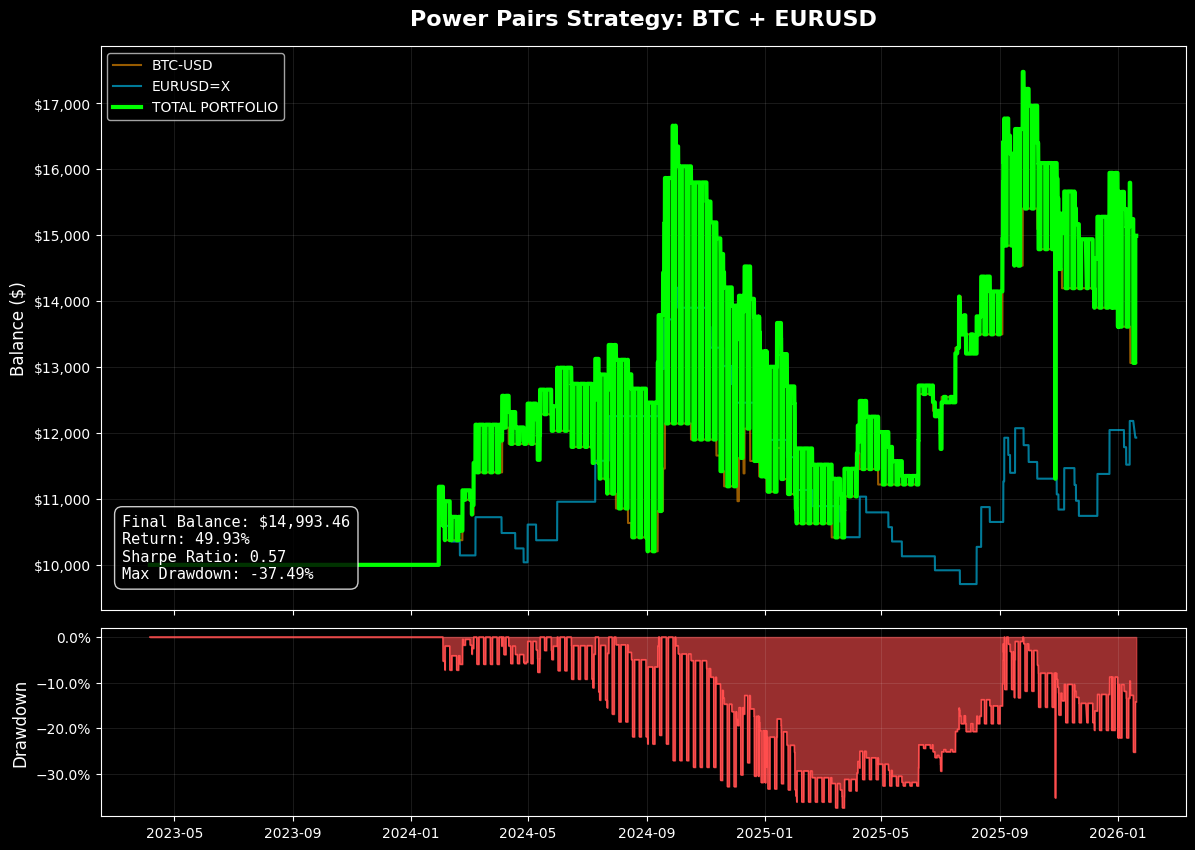

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# --- CONFIGURATION ---
# FOCUS ON THE WINNERS
ALL_TICKERS = ['BTC-USD', 'EURUSD=X']

# MACRO DATA (Still needed for Bias)
TICKERS_DATA = ['SPY', 'FEZ', '^TNX', 'CL=F'] 

# STRATEGY SETTINGS
INITIAL_CAPITAL = 10000
RISK_PCT = 0.02   # Increased to 2% (Since we have fewer, higher quality assets)

# --- 1. ASSET CONFIG ---
def get_asset_config(ticker, current_price):
    if "BTC" in ticker:
        # BTC: Higher volatility requires wider berth
        # Spread: $12 | Displacement: 0.6 (Stronger body required)
        return 0.01, 12.00, 'CRYPTO', 0.6 
    
    elif "EURUSD" in ticker:
        # EUR: Tight spreads, standard price action
        # Spread: 1.5 pips | Displacement: 0.5 (Standard body)
        return 0.0001, 0.00015, 'FOREX', 0.5
        
    return 0.01, 0.01, 'OTHER', 0.5

def get_trading_hours(ticker, timestamp):
    h = timestamp.hour
    # EURUSD: London (7-10) + NY (12-16)
    if "EURUSD" in ticker:
        if (h >= 7 and h <= 10) or (h >= 12 and h <= 16):
            return True
            
    # BTC: US Session Volatility (13:00 - 21:00 UTC)
    elif "BTC" in ticker:
        if h >= 13 and h <= 21: 
            return True
            
    return False

# --- 2. DATA LOADER ---
def get_data():
    print("1. Fetching Daily Macro Data...")
    macro = yf.download(TICKERS_DATA, period="2y", interval="1d", progress=False)['Close']
    macro = macro.ffill().dropna()
    
    asset_data = {}
    print("2. Fetching 1H Asset Data (Power Pairs)...")
    for ticker in ALL_TICKERS:
        print(f"   >> {ticker}")
        try:
            df = yf.download(ticker, period="730d", interval="1h", progress=False)
            if isinstance(df.columns, pd.MultiIndex):
                df = df.xs(ticker, level=1, axis=1)
            df.index = df.index.tz_localize(None)
            asset_data[ticker] = df.dropna()
        except Exception as e:
            print(f"Error fetching {ticker}: {e}")
            
    return macro, asset_data

# --- 3. MACRO BIAS ---
def get_macro_bias(macro_df):
    lb = 50
    growth = macro_df['SPY'] / macro_df['FEZ']
    score_growth = np.where(growth > growth.ewm(span=lb).mean(), -1, 1) 
    score_yield = np.where(macro_df['^TNX'] > macro_df['^TNX'].ewm(span=lb).mean(), -1, 1) 
    score_oil = np.where(macro_df['CL=F'] > macro_df['CL=F'].ewm(span=lb).mean(), -1, 1) 
    
    macro_df['Bias_Score'] = score_growth + score_yield + score_oil
    macro_df['Risk_State'] = 0
    macro_df.loc[macro_df['Bias_Score'] >= 1, 'Risk_State'] = 1  
    macro_df.loc[macro_df['Bias_Score'] <= -1, 'Risk_State'] = -1 
    
    return macro_df[['Risk_State']].shift(1).fillna(0)

# --- 4. BACKTEST CORE ---
def run_backtest(ticker, df, macro_bias):
    aligned_bias = macro_bias['Risk_State'].reindex(df.index, method='ffill').fillna(0)
    df['Bias'] = aligned_bias
    
    df['TR'] = np.maximum(df['High'] - df['Low'], abs(df['Close'] - df['Close'].shift(1)))
    df['ATR'] = df['TR'].rolling(14).mean()
    
    tick_size, spread, asset_class, disp_thresh = get_asset_config(ticker, df['Close'].iloc[-1])
    
    balance = INITIAL_CAPITAL
    equity_curve = []
    trades = [] 
    
    position = 0 
    entry_price = 0
    stop_loss = 0
    take_profit = 0
    units = 0
    
    active_eqh = []
    active_eql = []
    
    for i in range(20, len(df)):
        ts = df.index[i]
        o, h, l, c = df['Open'].iloc[i], df['High'].iloc[i], df['Low'].iloc[i], df['Close'].iloc[i]
        risk_state = df['Bias'].iloc[i]
        atr = df['ATR'].iloc[i]
        
        if np.isnan(atr): 
            equity_curve.append(balance)
            continue

        c_ref = i - 2
        # Pivot High
        if (df['High'].iloc[c_ref] > df['High'].iloc[c_ref-1]) and \
           (df['High'].iloc[c_ref] > df['High'].iloc[c_ref+1]) and \
           (df['High'].iloc[c_ref] > df['High'].iloc[i]):
            lvl = df['High'].iloc[c_ref]
            if not any(abs(lvl - x) < (5 * tick_size) for x in active_eqh):
                active_eqh.append(lvl)
                
        # Pivot Low
        if (df['Low'].iloc[c_ref] < df['Low'].iloc[c_ref-1]) and \
           (df['Low'].iloc[c_ref] < df['Low'].iloc[c_ref+1]) and \
           (df['Low'].iloc[c_ref] < df['Low'].iloc[i]):
            lvl = df['Low'].iloc[c_ref]
            if not any(abs(lvl - x) < (5 * tick_size) for x in active_eql):
                active_eql.append(lvl)

        if position != 0:
            risk_dist = abs(entry_price - stop_loss)
            pnl = 0
            trade_res = None
            
            if position == 1:
                if l <= stop_loss:
                    pnl = (stop_loss - entry_price) * units
                    pnl -= (spread * units)
                    trade_res = 'Loss'
                elif h >= take_profit:
                    pnl = (take_profit - entry_price) * units
                    pnl -= (spread * units)
                    trade_res = 'Win'
                elif (h - entry_price) > (1.5 * risk_dist) and stop_loss < entry_price:
                    stop_loss = entry_price + spread # BE

            elif position == -1:
                if h >= stop_loss:
                    pnl = (entry_price - stop_loss) * units
                    pnl -= (spread * units)
                    trade_res = 'Loss'
                elif l <= take_profit:
                    pnl = (entry_price - take_profit) * units
                    pnl -= (spread * units)
                    trade_res = 'Win'
                elif (entry_price - l) > (1.5 * risk_dist) and stop_loss > entry_price:
                    stop_loss = entry_price - spread

            if trade_res:
                balance += pnl
                trades.append({'Result': trade_res, 'PnL': pnl})
                position = 0

        active_eqh = [lvl for lvl in active_eqh if h < lvl]
        active_eql = [lvl for lvl in active_eql if l > lvl]
        
        if position == 0 and get_trading_hours(ticker, ts):
            
            trade_dir = 0
            if asset_class == 'FOREX':
                if risk_state == 1: trade_dir = 1
                elif risk_state == -1: trade_dir = -1
            else: # Crypto
                if risk_state == 1: trade_dir = 1
                elif risk_state == -1: trade_dir = -1

            body = abs(c - o)
            rng = h - l
            displacement = body > (disp_thresh * rng)
            
            if displacement and trade_dir != 0:
                if trade_dir == 1: # LONG
                    prev_lows = df['Low'].iloc[i-24:i].min()
                    if l < prev_lows and c > prev_lows:
                        position = 1
                        entry_price = c + spread
                        stop_loss = l - (0.5 * atr)
                        risk = entry_price - stop_loss
                        if risk > 0:
                            take_profit = entry_price + (3 * risk)
                            units = (balance * RISK_PCT) / risk
                            
                elif trade_dir == -1: # SHORT
                    prev_highs = df['High'].iloc[i-24:i].max()
                    if h > prev_highs and c < prev_highs:
                        position = -1
                        entry_price = c 
                        stop_loss = h + (0.5 * atr)
                        risk = stop_loss - entry_price
                        if risk > 0:
                            take_profit = entry_price - (3 * risk)
                            units = (balance * RISK_PCT) / risk

        equity_curve.append(balance)
        
    return pd.Series(equity_curve, index=df.index[-len(equity_curve):]), trades

# --- 5. DASHBOARD ---
if __name__ == "__main__":
    plt.style.use('dark_background')
    
    macro_df, asset_data = get_data()
    macro_bias = get_macro_bias(macro_df)
    
    portfolio_curve = None
    all_trades = []
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    
    print("\n--- POWER PAIRS: BTC & EURUSD (Risk: 2%) ---")
    print(f"{'TICKER':<10} {'TRADES':<8} {'WIN RATE':<10} {'REAL RR':<10} {'EV ($)':<10} {'MAX DD':<10} {'RETURN'}")
    print("-" * 85)
    
    colors = ['#ff9900', '#00ccff'] # Orange (BTC) and Blue (EUR)
    
    for i, (ticker, df) in enumerate(asset_data.items()):
        if df.empty: continue
        
        curve, trades = run_backtest(ticker, df, macro_bias)
        if len(trades) == 0: continue
            
        wins = [t['PnL'] for t in trades if t['Result'] == 'Win']
        losses = [t['PnL'] for t in trades if t['Result'] == 'Loss']
        
        wr = len(wins) / len(trades)
        avg_win = np.mean(wins) if wins else 0
        avg_loss = np.mean(losses) if losses else 0
        rr = abs(avg_win / avg_loss) if avg_loss != 0 else 0
        ev = (wr * avg_win) + ((1 - wr) * avg_loss)
        
        dd_series = ((curve - curve.cummax()) / curve.cummax()) * 100
        max_dd = dd_series.min()
        ret = ((curve.iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100
        
        print(f"{ticker:<10} {str(len(trades)):<8} {wr*100:>6.1f}%   {rr:>6.2f}R    ${ev:>6.2f}    {max_dd:>6.2f}%   {ret:>8.2f}%")
        
        norm_curve = curve - INITIAL_CAPITAL
        if portfolio_curve is None:
            portfolio_curve = norm_curve
        else:
            portfolio_curve = portfolio_curve.add(norm_curve, fill_value=0)
            
        all_trades.extend(trades)
        ax1.plot(curve.index, curve.values, alpha=0.6, linewidth=1.5, label=f"{ticker}", color=colors[i % len(colors)])

    # --- AGGREGATE ---
    portfolio_final = portfolio_curve + INITIAL_CAPITAL
    portfolio_final.index = pd.to_datetime(portfolio_final.index)
    
    daily = portfolio_final.resample('D').last().pct_change().dropna()
    sharpe = (daily.mean() / daily.std()) * (252**0.5) if daily.std() > 0 else 0
    p_dd = ((portfolio_final - portfolio_final.cummax()) / portfolio_final.cummax()) * 100
    p_max_dd = p_dd.min()
    
    # --- PLOTTING ---
    ax1.plot(portfolio_final.index, portfolio_final.values, color='#00ff00', linewidth=3, label='TOTAL PORTFOLIO')
    ax1.set_ylabel('Balance ($)', fontsize=12)
    ax1.set_title(f'Power Pairs Strategy: BTC + EURUSD', fontsize=16, fontweight='bold', pad=15)
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(color='white', alpha=0.1)
    
    formatter = mticker.StrMethodFormatter('${x:,.0f}')
    ax1.yaxis.set_major_formatter(formatter)
    
    stats_text = (
        f"Final Balance: ${portfolio_final.iloc[-1]:,.2f}\n"
        f"Return: {((portfolio_final.iloc[-1] - INITIAL_CAPITAL)/INITIAL_CAPITAL)*100:.2f}%\n"
        f"Sharpe Ratio: {sharpe:.2f}\n"
        f"Max Drawdown: {p_max_dd:.2f}%"
    )
    box_props = dict(boxstyle='round,pad=0.5', facecolor='black', alpha=0.8, edgecolor='white')
    ax1.text(0.02, 0.05, stats_text, transform=ax1.transAxes, fontsize=11, 
             verticalalignment='bottom', bbox=box_props, color='white', fontfamily='monospace')

    ax2.fill_between(p_dd.index, p_dd.values, 0, color='#ff4d4d', alpha=0.6)
    ax2.plot(p_dd.index, p_dd.values, color='#ff4d4d', linewidth=1)
    ax2.set_ylabel('Drawdown', fontsize=12)
    ax2.grid(color='white', alpha=0.1)
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
    
    plt.subplots_adjust(hspace=0.05)
    plt.show()

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# --- 1. FETCH DATA (Gold / XAUUSD) ---
# Note: 'GC=F' is Gold Futures on Yahoo Finance. 
# For Forex XAUUSD, you might need a different source or 'XAUUSD=X' if available.
ticker = "BTC-USD"  # Change to 'XAUUSD=X' or 'GC=F' for Gold
df = yf.download(ticker, period="5d", interval="5m") 

# Check if data is empty (Yahoo often has issues with 5m data for some tickers)
if df.empty:
    print("❌ No data fetched. Try a different ticker or timeframe.")
    exit()

# Flatten MultiIndex columns if necessary (common with new yfinance)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# --- 2. CALCULATE INDICATORS ---

# A. Trend Filter: 200 EMA
df['EMA_200'] = ta.ema(df['Close'], length=200)

# B. Stoch RSI (Default: 14, 14, 3, 3)
# pandas_ta returns two columns: STOCHRSIk (Fast) and STOCHRSId (Slow)
stoch_rsi = ta.stochrsi(df['Close'], length=14, rsi_length=14, k=3, d=3)
df = pd.concat([df, stoch_rsi], axis=1)

# Rename columns for easier access (names vary by version, so we standardize)
# Usually they are named 'STOCHRSIk_14_14_3_3' and 'STOCHRSId_14_14_3_3'
df['K'] = df.iloc[:, -2]  # The K line (Fast)
df['D'] = df.iloc[:, -1]  # The D line (Slow)

# --- 3. DEFINE STRATEGY LOGIC ---

def generate_signals(data):
    # Create empty signal columns
    data['Signal'] = 0       # 1=Buy, -1=Sell, 0=Hold
    data['Reason'] = ""
    
    # Loop through the data (starting from 200 to have EMA populated)
    # Note: Vectorization is faster, but looping is easier to read/debug for logic
    for i in range(200, len(data)):
        
        # Current and Previous values for Crossover check
        curr_k = data['K'].iloc[i]
        prev_k = data['K'].iloc[i-1]
        
        close_price = data['Close'].iloc[i]
        ema_value = data['EMA_200'].iloc[i]
        
        # --- BUY LOGIC ---
        # 1. Stoch RSI Crossover: K line crosses ABOVE 20
        crossover_up = (prev_k < 20) and (curr_k >= 20)
        
        # 2. Trend Filter: Price is ABOVE 200 EMA (Uptrend)
        trend_up = (close_price > ema_value)
        
        if crossover_up and trend_up:
            data.loc[data.index[i], 'Signal'] = 1
            data.loc[data.index[i], 'Reason'] = "Oversold Crossover + Uptrend"
            
        # --- SELL LOGIC ---
        # 1. Stoch RSI Crossover: K line crosses BELOW 80
        crossover_down = (prev_k > 80) and (curr_k <= 80)
        
        # 2. Trend Filter: Price is BELOW 200 EMA (Downtrend)
        trend_down = (close_price < ema_value)
        
        if crossover_down and trend_down:
            data.loc[data.index[i], 'Signal'] = -1
            data.loc[data.index[i], 'Reason'] = "Overbought Crossover + Downtrend"

    return data

# --- 4. RUN & PRINT ---
df_tested = generate_signals(df)

# Filter only rows with signals to see the action
signals_only = df_tested[df_tested['Signal'] != 0].tail(10)

print(f"--- LATEST SIGNALS FOR {ticker} ---")
print(signals_only[['Close', 'EMA_200', 'K', 'Signal', 'Reason']])

[*********************100%***********************]  1 of 1 completed


NameError: name 'ta' is not defined